# Reducción de dimensionalidad. PCA: Principal Component Analysis
#### UD3. Aprendizaxe non supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Ernesto Frías Nores

Para la elaboración de este notebook se ha tomado como referencia el material publicado en el libro: “An Introduction to Machine Learning with Python by Andreas C. Müller and Sarah Guido (O’Reilly). Copyright 2017 Sarah Guido and Andreas Müller, 978-1-449-36941-5.”


### **1. Componentes principales**

El análisis de componentes principales es un método que rota el conjunto de datos de forma que las características rotadas no estén estadísticamente correlacionadas. Esta rotación suele ir seguida de de las nuevas características, en función de su importancia para explicar los datos. explicar los datos. En la siguiente figura se ilustra el efecto del PCA en un conjunto de datos sintéticos bidimensionales:
<div style="text-align:center;">
    <img style="width:50%" src="data_transformation_PCA.png" />
</div>

El primer gráfico (arriba a la izquierda) muestra los puntos de datos originales, coloreados para distinguirlos entre ellos. El algoritmo procede a encontar primero la dirección de máxima varianza, denominada "Componente 1". Se trata de la dirección (o vector) de los datos que contiene la mayor parte de la información.Posteriormente, el algoritmo encuentra la dirección que contiene la información mayor información restante y que sea ortogonal (en ángulo recto) a la Componente 1. Se obtiene así, la 'Componente 2'. Para n dimensiones este proceso se repite hasta encontrar la i-ésima componente principal.

El segundo gráfico (arriba a la derecha) muestra los mismos datos, pero ahora girados de forma que el primer componente principal se alinee con el eje x y el segundo componente principal se alinee con el eje y. Antes de la rotación, se restó la media de los datos, de modo que los datos transformados se centran en torno a cero. En la epresentación rotada encontrada por PCA, los dos ejes no están correlacionados, lo que significa que la matriz de correlación de los datos en esta representación es cero, excepto en la diagonal.

Podemos utilizar el PCA para reducir la dimensionalidad reteniendo sólo algunos de las componentes principales. En el ejemplo de la figura, podríamos conservar sólo el primer componente principal, como se muestra en la Figura 3-3 (abajo a la izquierda). Esto reduce los datos a un conjunto de datos unidimensional.

En lugar de mantener sólo una de las características originales, lo que se ha hecho fue encontrar la dirección más 'interesante' y mantener esta dirección, el primer componente principal.

Por último, podemos deshacer la rotación y volver a añadir la media a los datos. El resultado mostrado en el último gráfico de la Figura. Estos puntos se encuentran en la imagen original. Estos puntos están en el espacio de características original, pero sólo hemos conservado la información contenida en el primer componente principal. Esta transformación se utiliza a veces para eliminar efectos de ruido de los datos o visualizar qué parte de la información se conserva utilizando los componentes principales.



### **2. PCA para la visualización de datos de alta dimensión**



Una de las aplicaciones más comunes del PCA es la visualización de conjuntos de datos de alta dimensión. Como hemos visto en problemas anteriores, es difícil crear gráficos de dispersión de datasets que tienen más de dos características. Para el dataset. Para el dataset Iris (4 características), podemos crear un gráfico de pares que nos dio una imagen parcial de los datos al mostrarnos todas las combinaciones posibles (6) de dos características. Pero si queremos analizar el dataset de Breast Cancer, incluso el uso de un gráfico de pares es complicado. Este conjunto de datos tiene 30 características, lo que daría como resultado 30 * 14 = 420 diagramas de dispersión! Nunca seríamos capaces de ver todos estos gráficos en detalle, y mucho menos de intentar comprenderlos.

Sin embargo, podemos utilizar una visualización aún más sencilla: calcular histogramas de cada una de las características para las dos clases.
cada una de las características de las dos clases, cáncer benigno y maligno.

In [3]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np


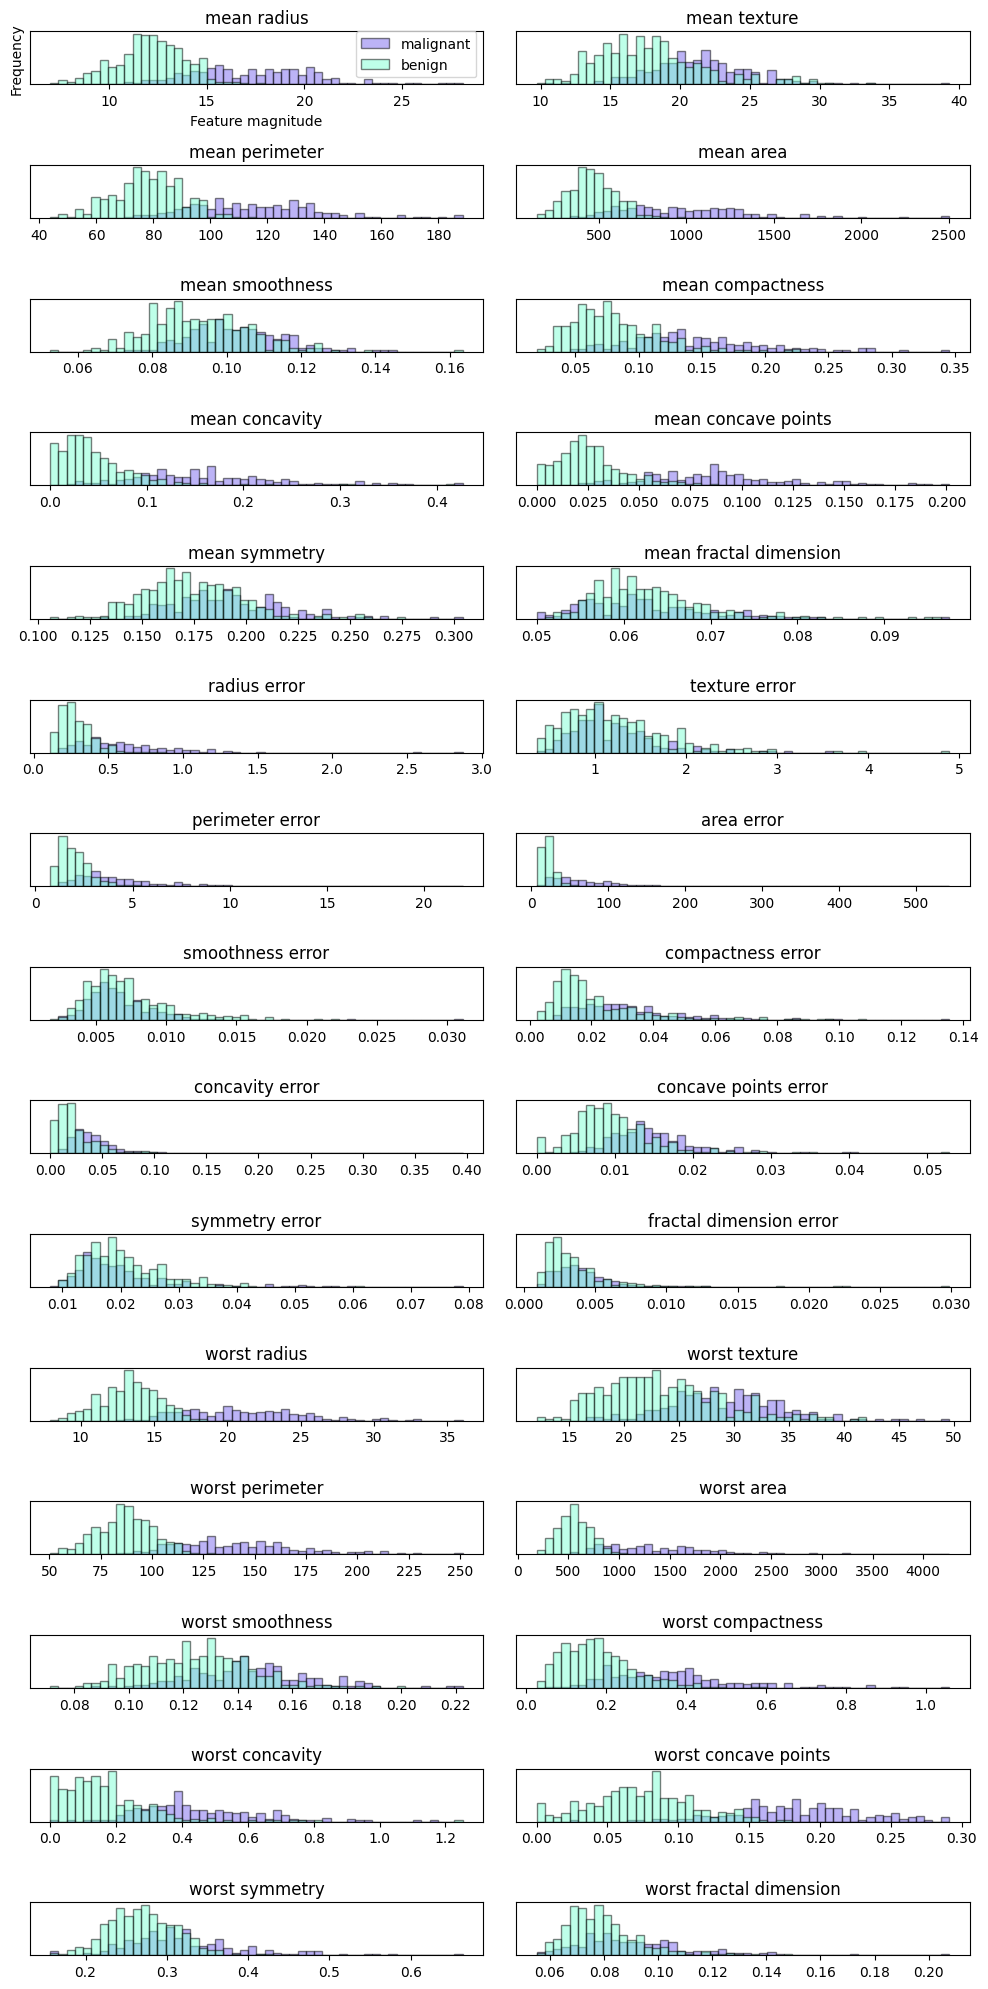

In [4]:
cancer = load_breast_cancer()
fig, axes = plt.subplots(15, 2, figsize=(10,20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

ax = axes.ravel()

for i in range(30):
  _, bins = np.histogram(cancer.data[:, i], bins=50)
  ax[i].hist(malignant[:, i], bins=bins, color='mediumslateblue', alpha=.5, ec='k')
  ax[i].hist(benign[:, i], bins=bins, color='aquamarine', alpha=.5, ec='k')
  ax[i].set_title(cancer.feature_names[i])
  ax[i].set_yticks(())
ax[0].set_xlabel("Feature magnitude")
ax[0].set_ylabel("Frequency")
ax[0].legend(["malignant", "benign"], loc="best")
fig.tight_layout()


En cada gráfico se superponen dos histogramas: uno para todos los puntos de la clase benigna (verde) y otro para todos los puntos de la clase maligna (azul). Esto nos da una idea de cómo se distribuye cada característica
entre las dos clases, y nos permite aventurar una conjetura sobre qué características son mejores para distinguir entre maligno y benigno. Por ejemplo, la característica "smoothness error" parece bastante poco informativa, porque los dos histogramas se solapan en su mayor parte,
mientras que la característica "worst concave points" parece bastante informativa, porque los histogramas están bastante separados.

Sin embargo, este gráfico no nos muestra nada sobre las interacciones entre variables y cómo éstas se relacionan con las clases. Utilizando PCA, podemos captar las principales interacciones y obtener una imagen algo más completa. Podemos encontrar los dos primeros componentes y visualizar los datos en este nuevo espacio bidimensional con un único gráfico de dispersión.

Antes de aplicar PCA, debemos escalar los datos para que tengan varianza unitaria.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

Para obtener los componentes principales con el módulo PCA de *scikit-learn* utilizaremos el método *fit()* y posteriormente aplicaremos la rotación y redución de la dimensionalidad llamando al método *transform()*

In [24]:
from sklearn.decomposition import PCA
# Mantenemos los dos componentes principales de los datos
pca = PCA(n_components=0.95)
# fit el modelo PCA al dataset de breast cancer
pca.fit(X_scaled)
# transformamos los datos sobre los dos primeros componentes principales
X_pca = pca.transform(X_scaled)
print("Tamaño original: {}".format(str(X_scaled.shape)))
print("Tamaño reducido: {}".format(str(X_pca.shape)))

Tamaño original: (569, 30)
Tamaño reducido: (569, 10)


Por defecto, el algoritmo PCA solo rota y desplaza los datos, manteniendo todas los componentes principales. Para reducir la dimensionalidad debemos especificar cuantos componentes queremos mantener (n_components). 

Ahora podemos visualizar los dos componentes principales

In [25]:
X_pca

array([[ 9.19283683,  1.94858307, -1.12316616, ..., -0.39840723,
        -0.15711836, -0.87740188],
       [ 2.3878018 , -3.76817174, -0.52929269, ...,  0.24098846,
        -0.71190482,  1.10699494],
       [ 5.73389628, -1.0751738 , -0.55174759, ...,  0.09737374,
         0.02406564,  0.4542754 ],
       ...,
       [ 1.25617928, -1.90229671,  0.56273053, ...,  0.34188704,
         0.39391682,  0.52087738],
       [10.37479406,  1.67201011, -1.87702933, ..., -0.28023861,
        -0.54203454, -0.08929612],
       [-5.4752433 , -0.67063679,  1.49044308, ...,  1.04635352,
         0.37410111, -0.04772557]], shape=(569, 10))

Text(0, 0.5, 'Second principal component')

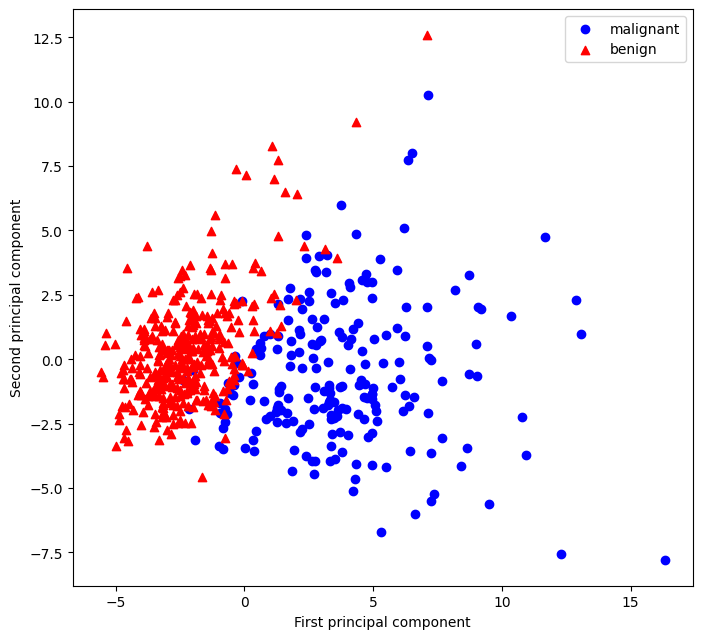

In [28]:
# visualizamos el primer y segundo componentes principales, coloreados por clase
plt.figure(figsize=(8, 8))
plt.scatter(X_pca[cancer.target==0, 0], X_pca[cancer.target==0, 1], c='b')
plt.scatter(X_pca[cancer.target==1, 0], X_pca[cancer.target==1, 1], marker='^', c='r')
plt.legend(cancer.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

In [27]:
pca.explained_variance_ratio_

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768,
       0.04024522, 0.02250734, 0.01588724, 0.01389649, 0.01168978])

Es importante señalar que el PCA es un método no supervisado, y no utiliza ninguna información de clase al calcular la rotación. Simplemente observa las correlaciones en los datos.

Para el gráfico de dispersión que se muestra aquí, visualizamos el primer componente principal contra el segundo componente principal, y luego utilizamos la información de clase para colorear los puntos.
Se puede ver que las dos clases se separan bastante bien en este espacio bidimensional.

Esto nos lleva a creer que incluso un clasificador lineal (que aprendería una línea en este espacio) podría distinguir razonablemente bien las dos clases. 

También podemos observar, que los puntos malignos están más dispersos que los benignos, algo que que ya podíamos ver un poco en los histogramas.

Un inconveniente del PCA es que los dos ejes del gráfico no suelen ser muy interpretables. Los componentes principales corresponden a direcciones en los datos originales, por lo que son combinaciones de las características originales. Sin embargo, estas combinaciones suelen ser muy complejas. Los componentes principales se almacenan en el atributo components_ del objeto PCA durante el ajuste:

In [10]:
print("Componentes PCA:\n{}".format(pca.components_))

Componentes PCA:
[[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


### **3. PCA para la extracción de características**

Otra aplicación importnate del PCA  es la extracción de características. La idea que hay detrás de la extracción de características es que es posible encontrar una representación de los datos que sea más adecuada para el análisis que la representación en bruto que se le dio. Un buen ejemplo de una aplicación en la que la extracción de características es útil son las imágenes. Las imágenes están formadas por píxeles, normalmente almacenados como intensidades de color rojo, verde y azul (RGB).
Los objetos de las imágenes suelen estar formados por miles de píxeles, y sólo juntos son significativos.

Veremos una aplicación muy sencilla de la extraccón de características empleando PCA con el dataset Labeled Faces in the Wild. Este dataset contiene imágenes de rostros de famosos de principios de la década 200 descargadas de internet.

Utilizaremos versiones en escala de grises de las imágenes y las reduciremos para procesarlas más rápidamente. A continuación mostramos algunas de las imágenes:

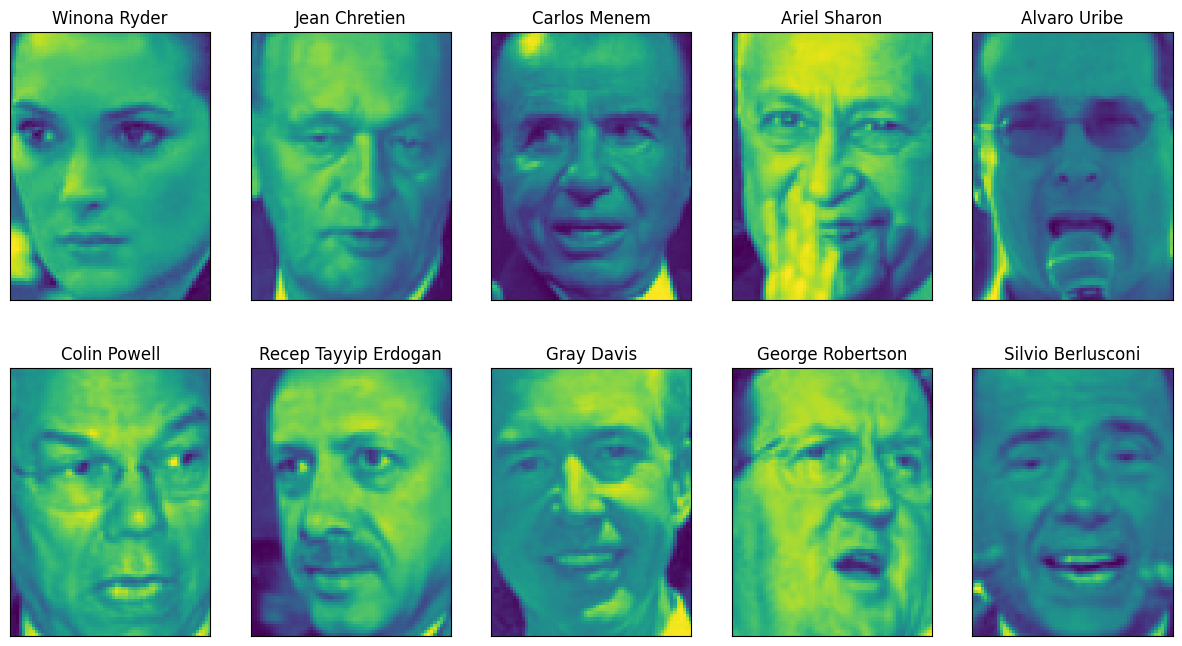

In [11]:
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
subplot_kw={'xticks': (), 'yticks': ()})

for target, image, ax in zip(people.target, people.images, axes.ravel()):
  ax.imshow(image)
  ax.set_title(people.target_names[target])

In [31]:
print("Tamaño de las imágenes: {}".format(people.images.shape))
print("Número de clases: {}".format(len(people.target_names)))


Tamaño de las imágenes: (3023, 87, 65)
Número de clases: 62


Hay 3023 imágenes de 87x65 píxeles que pertenecen a 62 personas diferentes.

Veamos como está distribuido el dataset:

In [32]:
# count how often each target appears
counts = np.bincount(people.target)
# print counts next to target names
for i, (count, name) in enumerate(zip(counts, people.target_names)):
  print("{0:25} {1:3}".format(name, count), end=' ')
  if (i + 1) % 3 == 0:
    print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

El dataset está un poco sesgado, ya que contiene muchas imágenes de George W. Bush y Colin Powell. Para que los datos estén menos sesgados, sólo tomaremos hasta 50 imágenes de cada persona (de lo contrario, la extracción de características se vería desbordada por la probabilidad de que sea George
W. Bush)

In [14]:
mask = np.zeros(people.target.shape, dtype=bool)
for target in np.unique(people.target):
  mask[np.where(people.target == target)[0][:50]] = 1
X_people = people.data[mask]
y_people = people.target[mask]
# escalamos los valores de la escala de grises al intervalo 0-1
# en lugar de 0 y 255 para mejor estabilidad numérica
X_people = X_people / 255.

Una tarea común en el reconocimiento facial es preguntar si una cara no vista previamente pertenece a una persona conocida de una base de datos. Esto tiene aplicaciones en recopilación de fotografías, redes sociales y aplicaciones de seguridad. Una forma de resolver este problema sería construir un clasificador en el que cada persona fuera una clase independiente. Sin embargo, suele haber muchas personas diferentes en las bases de datos de rostros y muy pocas imágenes de la misma persona (es decir, muy pocos ejemplos de entrenamiento por clase). Esto dificulta el entrenamiento de la mayoría de los clasificadores. Además, a menudo se desea poder añadir nuevas personas con facilidad, sin necesidad de volver a entrenar un modelo grande.

Una solución sencilla es utilizar un clasificador KNN que busque la imagen facial más similar a la cara que se está clasificando. En principio, este clasificador podría trabajar con un solo ejemplo de entrenamiento por clase. Veamos qué tal funciona KNeighborsClassifier:

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# dividimos los datos en los conjuntos de training and test
X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=0)
# Construimos un KNeighborsClassifier con k=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
print("Test set score of 1-nn: {:.2f}".format(knn.score(X_test, y_test)))

Test set score of 1-nn: 0.22


Obtenemos una precisión de un 22%, la cual no es realmente mala teniendo en cuenta que se trata de unn problema de clasificación de 62 clases (con una clasificación al azar obtendríamos aproximadamente una precisión de 1/62 = 1.6%) pero tampoco es genial. Solo identificicamos una persona correctamente una de cinco veces.

Calcular distancias en el espacio de píxeles original es una forma bastante mala de medir la similitud entre caras ya que utilizar distancias de píxeles significa que desplazar un rostro un píxel a la derecha corresponde a un cambio drástico, con una representación completamente distinta. Esperamos que el uso de distancias a lo largo de los componentes principales puede mejorar nuestra precisión. En este caso, activamos la opción de blanqueamiento de PCA, que cambia la escala de los componentes principales para que tengan la misma escala. Esto es lo mismo que usar StandardScaler después de la transformación. 

<div style="text-align:center;">
    <img style="width:50%" src="whitening_data.png" />
</div>

Ajustamos un modelo PCA a los datos de entrenamiento y extraemos los primeros 100 componentes principales. Luego transformamos los datos de entrenamiento y pueba.

In [16]:
pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("X_train_pca.shape: {}".format(X_train_pca.shape))

X_train_pca.shape: (1547, 100)


In [34]:
print(pca.explained_variance_ratio_.sum())
pca.explained_variance_ratio_   

0.9515688143366668


array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768,
       0.04024522, 0.02250734, 0.01588724, 0.01389649, 0.01168978])

Los nuevos datos tienen 100 características (100 componentes principales). Ahora podemos usar la nueva representación para clasificar las imágenes unsando un clasificador 1-nn:

In [17]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)
print("Test set accuracy: {:.2f}".format(knn.score(X_test_pca, y_test)))

Test set accuracy: 0.30


La precisión mejoró notablemente, del 22% al 30%, lo que confirma la intuición de que los componentes principales podrían ofrecer una mejor representación de los datos.

En el caso de los datos de imagen, también podemos visualizar fácilmente los componentes principales encontrados.

Los componentes corresponden a direcciones en el espacio de entrada. El espacio de entrada aquí son imágenes en escala de grises de 87×65 píxeles, por lo que las direcciones dentro de este espacio también son imágenes en escala de grises de 87×65 píxeles.

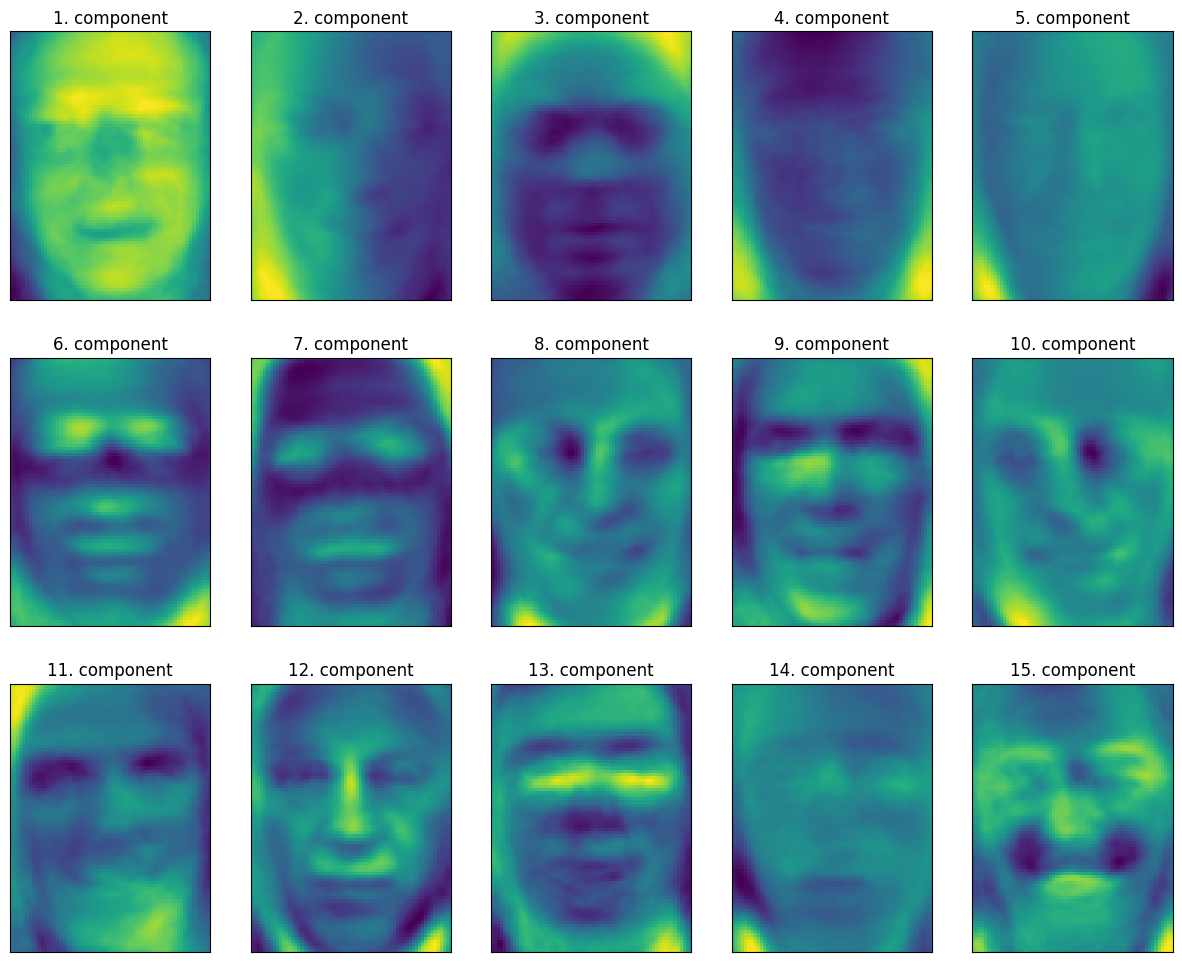

In [18]:
fix, axes = plt.subplots(3, 5, figsize=(15, 12),
subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(pca.components_, axes.ravel())):
  ax.imshow(component.reshape(image_shape), cmap='viridis')
  ax.set_title("{}. component".format((i + 1)))

Otra forma de intentar comprender lo que hace un modelo PCA es observar las reconstrucciones de los datos originales utilizando sólo algunos componentes. Podemos hacer una transformación reduciendo los datos a sólo algunos componentes principales y volviendo a rotar al espacio original. Este retorno al espacio de características original puede hacerse utilizando el método inverse_transform. En la siguiente figura visualizamos la reconstrucción de algunos rostros utilizando 10, 50, 100 o 500 componentes principales.
<div style="text-align:center;">
    <img style="width:50%" src="faces_reconstruction.png" />
</div>

Se puede ver que cuando utilizamos solo los 10 primeros componentes principales, únicamente se capta la esencia de la imagen, como la orientación de la cara y la iluminación. Al utilizar cada vez más componentes principales, se conservan cada vez más detalles de la imagen. Utilizar tantos componentes como píxeles significaría que no descartaríamos información después de la rotación, y reconstruiríamos la imagen perfectamente.